In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb

import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr

In [3]:
import met_brewer

In [4]:
import scanpy as sc
import logomaker as lm
import matplotlib.patches as patches

from scipy.stats import ttest_ind

In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Settings

In [6]:
TEXT_WIDTH = 6.7261  # in
DPI = 360

def set_font_size(font_size):
    plt.rc('font', size=font_size)          # controls default text sizes
    plt.rc('axes', titlesize=font_size)     # fontsize of the axes title
    plt.rc('axes', labelsize=font_size)     # fontsize of the x and y labels
    plt.rc('xtick', labelsize=font_size)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=font_size)    # fontsize of the tick labels
    plt.rc('legend', fontsize=font_size, title_fontsize=font_size)    # legend fontsize
    plt.rc('figure', titlesize=font_size)   # fontsize of the figure title

In [7]:
sb.set(context='paper', style='whitegrid')
plt.rc('grid', linewidth=0.3)
sb.set_palette('colorblind')
set_font_size(6)

In [8]:
epitopes = ['LTDEMIAQY', 'YLQPRTFLL']
model = 'Base'

## Colors

In [9]:
palette_epitopes = met_brewer.met_brew(name='Redon', n=12, brew_type='discrete')
palette_epitopes = {
    'LTD': palette_epitopes[-1],
    'YLQ': palette_epitopes[1],
}

In [10]:
palette_epitopes_ext = met_brewer.met_brew(name='Redon', n=12, brew_type='discrete')
palette_epitopes_ext = {
    'LTD_spec': palette_epitopes['LTD'],
    'LTD_unspec': 'lightgray',
    'YLQ_spec': palette_epitopes['YLQ'],
    'YLQ_unspec': 'lightgray',
}

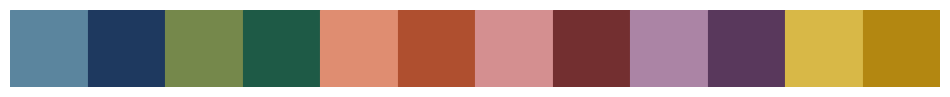

In [11]:
colors_tmp = met_brewer.met_brew(name='Redon', n=12, brew_type='discrete')

fig, ax = plt.subplots(figsize=(len(colors_tmp), 1))
for i, c in enumerate(colors_tmp):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
ax.set_xlim(0, len(colors_tmp))
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

# Load data
## UMAP

In [12]:
adata = sc.read('../results/kocher/adata_processed.h5ad')

## TULIP-Prediction

In [13]:
df_prediction = pd.read_csv('../results/kocher/ePytope_prediction.csv', index_col=0)

## Distances

In [14]:
df_dist_pairs = pd.read_csv('../results/kocher/pairwise_distances.csv', index_col=0)
df_dist_pairs['sameSpec'] = df_dist_pairs['sameSpec'].str.lower() 

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\4294604369.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dist_pairs = pd.read_csv('../results/kocher/pairwise_distances.csv', index_col=0)


In [15]:
df_nn_ltd = pd.read_csv('../results/kocher/tcrdist_stacked_ltd.csv', index_col=0)
df_nn_ltd = df_nn_ltd[df_nn_ltd.index.isin(['Random', '1.0'])]
df_nn_ltd.index = df_nn_ltd.index.map({'Random': 'Random', '1.0': 'LTD'})
df_nn_ltd = df_nn_ltd.reset_index()
df_nn_ltd.columns = ['Group', 'Other', 'LTD']
df_nn_ltd = df_nn_ltd[['Group', 'LTD']]
df_nn_ltd

,Group,LTD
0,Random,0.00745
1,LTD,0.27451


In [16]:
df_nn_ylq= pd.read_csv('../results/kocher/tcrdist_stacked_ylq.csv', index_col=0)
df_nn_ylq = df_nn_ylq[df_nn_ylq.index.isin(['Random', '1.0'])]
df_nn_ylq.index = df_nn_ylq.index.map({'Random': 'Random', '1.0': 'YLQ'})
df_nn_ylq = df_nn_ylq.reset_index()
df_nn_ylq.columns = ['Group', 'Other', 'YLQ']
df_nn_ylq = df_nn_ylq[['Group', 'YLQ']]
df_nn_ylq

,Group,YLQ
0,Random,0.002971
1,YLQ,0.689189


In [17]:
df_nn_ylq.loc[1, 'YLQ'] - df_nn_ylq.loc[0, 'YLQ']

np.float64(0.6862184803780669)

In [18]:
df_nn_ltd.loc[1, 'LTD'] - df_nn_ltd.loc[0, 'LTD']

np.float64(0.2670599079001788)

## Purity

In [19]:
df_purity = pd.read_csv('../results/kocher/clonal_purity.csv', index_col=0)
#df_purity['Name'] = df_purity['Name'].replace({'Positive': 'Specific', 
#                                                'Positive Expanded': 'Specific expanded'})
df_purity['Expanded'] = ['All', 'Expanded', 'All', 'Expanded']
df_purity['Specific'] = ['any', 'any', 'LTD/YLQ', 'LTD/YLQ']

In [20]:
df_purity

,Name,Purity,Expanded,Specific
0,All,0.999503,All,any
1,Expanded,0.997219,Expanded,any
2,Positive,0.942244,All,LTD/YLQ
3,Postive Expanded,0.873064,Expanded,LTD/YLQ


In [21]:
df_purity_all = pd.read_csv('../results/kocher/purity_expansion_all.csv', index_col=0)

## Performance

In [80]:
from scipy.stats import ttest_rel

In [22]:
results_class = pd.read_csv('../results/kocher/classification_metrics.csv', index_col=0)
results_class = results_class[results_class['Metric'].isin(['F1-Score', 'Accuracy'])]
results_class = results_class[results_class['Baseline']=='paper']
results_class['Metric'] = results_class['Metric'].replace({'F1-Score': 'F1', 'Accuracy': 'Acc'})
results_class

,Method,Epitope,Experiment,Baseline,Metric,Value
28,Base,LTD,first,paper,F1,1.000000
29,Base,LTD,first,paper,Acc,1.000000
32,Base,YLQ,first,paper,F1,1.000000
33,Base,YLQ,first,paper,Acc,1.000000
64,Base,LTD,second,paper,F1,0.916031
65,Base,LTD,second,paper,Acc,0.986058
68,Base,YLQ,second,paper,F1,0.887218
69,Base,YLQ,second,paper,Acc,0.993663
100,Base,LTD,third,paper,F1,0.808989
101,Base,LTD,third,paper,Acc,0.950244


In [58]:
results_class[(results_class['Metric']=='Acc')].groupby(['Method', 'Epitope'])['Value'].min()

Method      Epitope
Base        LTD        0.950244
            YLQ        0.992593
CloneModel  LTD        0.960000
            YLQ        0.992593
Name: Value, dtype: float64

In [62]:
results_class[(results_class['Metric']=='Acc')].groupby(['Method'])['Value'].mean()

Method
Base          0.987093
CloneModel    0.989353
Name: Value, dtype: float64

In [63]:
results_class[(results_class['Metric']=='Acc')].groupby(['Method'])['Value'].std()

Method
Base          0.018791
CloneModel    0.014932
Name: Value, dtype: float64

In [64]:
results_class[(results_class['Metric']=='F1')].groupby(['Method', 'Epitope'])['Value'].min()

Method      Epitope
Base        LTD        0.808989
            YLQ        0.887218
CloneModel  LTD        0.851986
            YLQ        0.878788
Name: Value, dtype: float64

In [65]:
results_class[(results_class['Metric']=='F1')].groupby(['Method'])['Value'].mean()

Method
Base          0.925569
CloneModel    0.935813
Name: Value, dtype: float64

In [66]:
results_class[(results_class['Metric']=='F1')].groupby(['Method'])['Value'].std()

Method
Base          0.072768
CloneModel    0.060989
Name: Value, dtype: float64

In [70]:
np.diff(results_class[(results_class['Metric']=='Acc')].groupby(['Method'])['Value'].mean())

array([0.00225973])

In [69]:
np.diff(results_class[(results_class['Metric']=='F1')].groupby(['Method'])['Value'].mean())

array([0.01024402])

In [83]:
tmp = results_class[(results_class['Metric']=='Acc')]
val1 = tmp[tmp['Method']=='Base']['Value'].values
val2 = tmp[tmp['Method']=='CloneModel']['Value'].values
ttest_rel(val1, val2)

TtestResult(statistic=np.float64(-1.3620887680312819), pvalue=np.float64(0.23132198358855335), df=np.int64(5))

In [84]:
tmp = results_class[(results_class['Metric']=='F1')]
val1 = tmp[tmp['Method']=='Base']['Value'].values
val2 = tmp[tmp['Method']=='CloneModel']['Value'].values
ttest_rel(val1, val2)

TtestResult(statistic=np.float64(-1.2503786004660062), pvalue=np.float64(0.26648912074225733), df=np.int64(5))

In [23]:
results_score = pd.read_csv('../results/kocher/separation_metrics.csv', index_col=0)
results_score = results_score[results_score['Baseline']=='paper']
results_score

,Method,Epitope,Experiment,Baseline,Metric,Value
14,Base,LTD,first,paper,AUC,1.000000
15,Base,LTD,first,paper,APS,1.000000
16,Base,YLQ,first,paper,AUC,1.000000
17,Base,YLQ,first,paper,APS,1.000000
32,Base,LTD,second,paper,AUC,0.983997
33,Base,LTD,second,paper,APS,0.961698
34,Base,YLQ,second,paper,AUC,0.965297
35,Base,YLQ,second,paper,APS,0.928802
50,Base,LTD,third,paper,AUC,0.970507
51,Base,LTD,third,paper,APS,0.956786


In [49]:
results_score[(results_score['Metric']=='AUC')].groupby(['Method', 'Epitope'])['Value'].min()

Method      Epitope
Base        LTD        0.970507
            YLQ        0.965297
CloneModel  LTD        0.983322
            YLQ        0.954061
Name: Value, dtype: float64

In [52]:
results_score[(results_score['Metric']=='AUC')].groupby(['Method'])['Value'].mean()

Method
Base          0.986470
CloneModel    0.989319
Name: Value, dtype: float64

In [71]:
np.diff(results_score[(results_score['Metric']=='AUC')].groupby(['Method'])['Value'].mean())

array([0.0028496])

In [53]:
results_score[(results_score['Metric']=='AUC')].groupby(['Method'])['Value'].std()

Method
Base          0.015702
CloneModel    0.018468
Name: Value, dtype: float64

In [50]:
results_score[(results_score['Metric']=='APS')].groupby(['Method', 'Epitope'])['Value'].min()

Method      Epitope
Base        LTD        0.956786
            YLQ        0.928802
CloneModel  LTD        0.975309
            YLQ        0.934545
Name: Value, dtype: float64

In [54]:
results_score[(results_score['Metric']=='APS')].groupby(['Method'])['Value'].mean()

Method
Base          0.972233
CloneModel    0.981871
Name: Value, dtype: float64

In [55]:
results_score[(results_score['Metric']=='APS')].groupby(['Method'])['Value'].std()

Method
Base          0.02818
CloneModel    0.02505
Name: Value, dtype: float64

In [75]:
np.diff(results_score[(results_score['Metric']=='APS')].groupby(['Method'])['Value'].mean())

array([0.00963884])

In [81]:
tmp = results_score[(results_score['Metric']=='APS')]
val1 = tmp[tmp['Method']=='Base']['Value'].values
val2 = tmp[tmp['Method']=='CloneModel']['Value'].values
ttest_rel(val1, val2)

TtestResult(statistic=np.float64(-1.7170717580313997), pvalue=np.float64(0.14661441646369688), df=np.int64(5))

In [82]:
tmp = results_score[(results_score['Metric']=='AUC')]
val1 = tmp[tmp['Method']=='Base']['Value'].values
val2 = tmp[tmp['Method']=='CloneModel']['Value'].values
ttest_rel(val1, val2)

TtestResult(statistic=np.float64(-0.710504422881367), pvalue=np.float64(0.5091485783940846), df=np.int64(5))

## Motifs

In [24]:
sequences = {n.upper(): pd.read_csv(f'../results/kocher/selected_sequences_{n}.csv', index_col=0) for n in ['ltd', 'ylq']}

In [25]:
df_precision_ltd = pd.read_csv('../results/kocher/precision_motif_query_ltd.csv', index_col=0)
df_precision_ltd['Method'] = df_precision_ltd['Method'].replace({'V-J': 'V29-1\nJ2-7',
                                                                 'V-J+GWPY': 'V29-1\nJ2-7\nGWPY'})
df_precision_ltd

,Method,Precision,n_pos
0,All,0.001897,133
4,V29-1\nJ2-7,0.020253,8
2,GWP,0.304348,7
1,WPY,0.583333,7
3,GWPY,0.875000,7
5,V29-1\nJ2-7\nGWPY,1.000000,7


In [26]:
df_precision_ylq = pd.read_csv('../results/kocher/precision_motif_query_ylq.csv', index_col=0)
df_precision_ylq['Method'] = df_precision_ylq['Method'].replace({'J-gene': 'J2-2',
                                                                 'J+NTGELF': 'J2-2\nNTGELF'})
df_precision_ylq = df_precision_ylq[df_precision_ylq['Method']!='J2-2\nNTGELF'].copy()

In [27]:
df_precision_ylq = df_precision_ylq[df_precision_ylq['Method']!='J2-2']

# Plotting functions
## Umaps

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\4021991066.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend(loc='upper right', frameon=False)


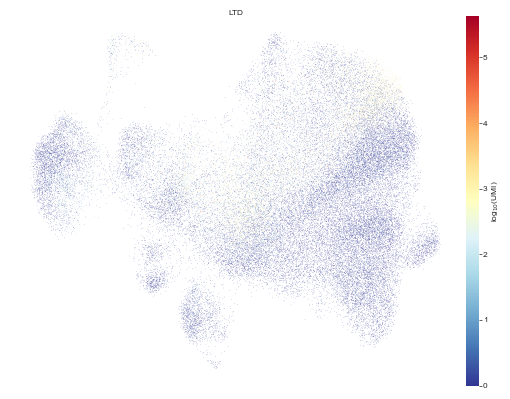

In [28]:
def plot_umi_umap(epitope, ax=None):
    plot = sc.pl.umap(adata[adata.obs[epitope].isna()], 
                         size=12000/len(adata) * 6/6,
                      show=False, ax=ax)
    plot = sc.pl.umap(adata[adata.obs[epitope].notna()], 
                      color=f'log_{epitope}', 
                      cmap='RdYlBu_r', size=12000/len(adata) * 12/6,
                      ax=plot,
                      show=False,)

    plot.set_xlabel(None)
    plot.set_ylabel(None)
    plot.set_title(None)

    plot.legend(loc='upper right', frameon=False)

    sb.despine(ax=plot, left=True, bottom=True)

    cbar = plot.collections[1].colorbar
    cbar.outline.set_visible(False)
    cbar.set_label('log$_{10}$(UMI)')
    cbar.ax.tick_params(length=2, width=0.5, #color=(0.8, 0.8, 0.8, 1.0), 
                        pad=1)
    cbar.ax.yaxis.labelpad = 2 
    
    plot.set_title(f'{epitope[:3]}', pad=0)

plot_umi_umap('LTDEMIAQY')

C:\Users\felix.drost\Anaconda3\envs\dextra\lib\site-packages\scanpy\plotting\_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


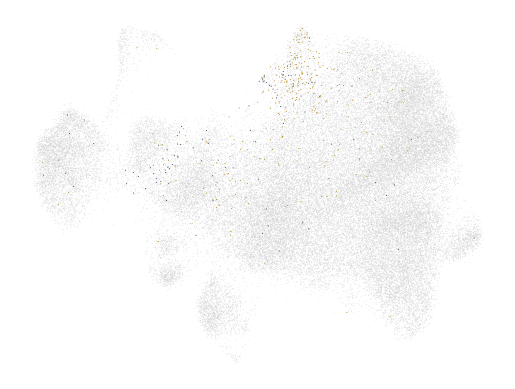

In [29]:
def plot_umap_binding(ax=None):
    plot = sc.pl.umap(adata[adata.obs['Base'].isna()], size=12000/len(adata) * 30/6,
                      show=False, ax=ax)
    
    plot = sc.pl.umap(adata[adata.obs['Base'].notna()], color='Base', size=12000/len(adata) * 60/6,
                      show=False, ax=plot, palette=palette_epitopes)

    plot.set_xlabel(None)
    plot.set_ylabel(None)
    plot.set_title(None)

    plot.legend().remove()  # loc='upper right', frameon=False)

    sb.despine(ax=plot, left=True, bottom=True)

plot_umap_binding()

## Violins

In [30]:
def pval_to_sign(pval):
    if np.isnan(pval):
        return 'nan'
    if pval < 0.001:
        return '***'
    if pval < 0.01:
        return '**'
    if pval < 0.05:
        return '*'
    return ''

LTDEMIAQY
6.749749337997426e-12
YLQPRTFLL
0.0


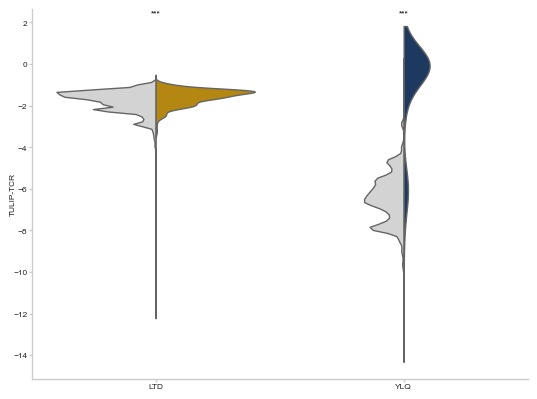

In [31]:
def plot_violin(df, ax=None):
    plot = sb.violinplot(data=df, x='Epitope', order=[el[:3] for el in epitopes],
                  y='ePytope', hue=model, hue_order=['Unspecific', 'Specific'],
                  ax=ax, split=True, inner=None, linewidth=1,
                  palette={'Specific': 'darkgray', 'Unspecific': 'lightgray'}
                 )

    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('TULIP-TCR', labelpad=-2)
    plot.set_xlabel(None)
    plot.legend().remove()  # bbox_to_anchor=(0, 1), loc='lower center', ncols=2, frameon=False)
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    
    for i, epitope in enumerate(epitopes):
        df_tmp = df[df['Epitope']==epitope[:3]]
        df_tmp = df_tmp[df_tmp['ePytope'].notna()]
        _, pval = ttest_ind(df_tmp[df_tmp[model]=='Unspecific']['ePytope'].values, 
                            df_tmp[df_tmp[model]=='Specific']['ePytope'].values, )
        print(epitope)
        print(pval)
        
        y_max = plot.get_ylim()[1]
        plot.text(i, y_max, pval_to_sign(pval), ha='center', va='top', weight='bold')
        
    for i, collection in enumerate(plot.collections):
        path = collection.get_paths()[0]
        x_center = path.vertices[:, 0].mean()
        ep = 'LTD' if x_center < 0.5 else 'YLQ'
        spec = 'unspec' if i%2==0 else 'spec'
            
        color = f'{ep}_{spec}'
        collection.set_facecolor(palette_epitopes_ext[color])
    
plot_violin(df_prediction, ax=None)

## Fraction nearest neighbors

In [32]:
import matplotlib.patches as mpatches

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\3856691868.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()


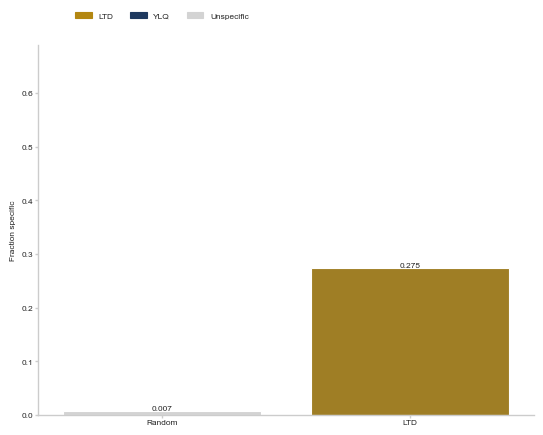

In [33]:
palette_epitopes_ext2 = {
    'LTD': {'LTD': palette_epitopes['LTD'],
            'Random': 'lightgray'},
    'YLQ': {'YLQ': palette_epitopes['YLQ'],
            'Random': 'lightgray'}
}
vmax_nn = max(df_nn_ltd['LTD'].max(), df_nn_ylq['YLQ'].max())

legend = {
    'LTD': palette_epitopes['LTD'],
    'YLQ': palette_epitopes['YLQ'],
    'Unspecific': 'lightgray',
}

def plot_nn(df, do_yaxis=True, ax=None):
    epi = 'LTD' if 'LTD' in df['Group'].values else 'YLQ'
    plot = sb.barplot(data=df, x='Group', y=epi, palette=palette_epitopes_ext2[epi], ax=ax)
    #df.plot(kind='bar', stacked=False, ax=ax, 
    #               width=0.9,
    #               color=palette_epitopes_ext2[epi])
    
    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Fraction specific')
    plot.set_xlabel(None)
    plot.legend().remove()
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    
    plot.set_ylim(0, vmax_nn)
    
    if not do_yaxis:
        plot.yaxis.set_visible(False)
        sb.despine(ax=plot, left=True)
        plot.legend().remove()
    else:
        handels = [mpatches.Patch(color=v, label=n) for n, v in legend.items()]
        plot.legend(handles=handels, loc="lower center", ncols=3, 
                    bbox_to_anchor=(0.25, 1.05),
                    frameon=False)
    
    for container in plot.containers:
        plot.bar_label(container, fmt="%.3f")

plot_nn(df_nn_ltd)

## Purity

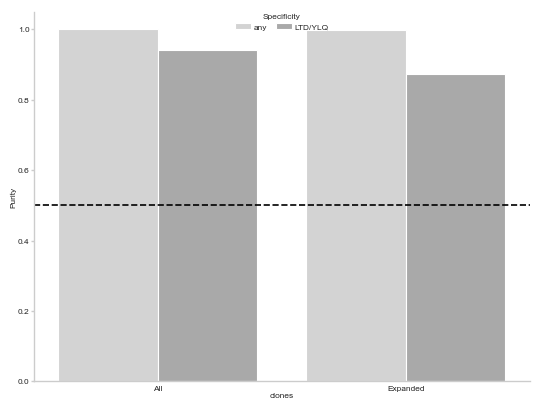

In [34]:
def plot_purity(ax=None):
    plot = sb.barplot(data=df_purity, x='Expanded', hue='Specific', y='Purity', ax=ax,
                     palette={'LTD/YLQ': 'darkgray', 'any': 'lightgray'})
    
    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Purity', labelpad=1)
    plot.set_xlabel('clones', labelpad=1)
    
    plot.legend(bbox_to_anchor=(0.5, 0.93), loc='lower center', ncols=2, frameon=False, title='Specificity',
                columnspacing=1, handletextpad=0.3)
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    
    plot.axhline(0.5, linestyle='--', color='black')
    
plot_purity()

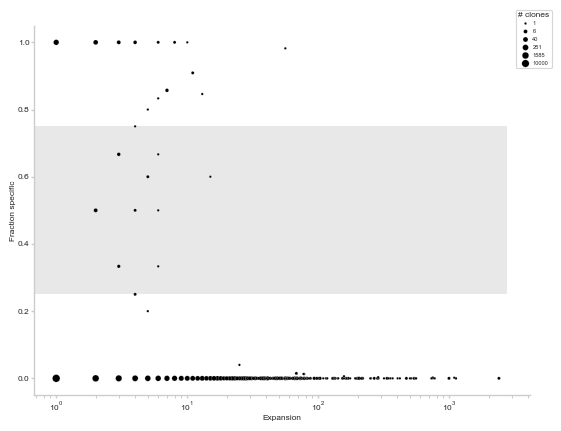

In [35]:
def plot_purity_expansion(df, ax=None):
    plot = sb.scatterplot(data=df, x='Expansion', y='% Pos', size='Log # clones', color='black', sizes=(3, 30), ax=ax)

    band = patches.Rectangle((0, 0.25), plot.get_xlim()[1]*1.1, 0.5, color='lightgray', zorder=0, alpha=0.5, linewidth=0)
    plot.add_patch(band)

    plot.set_xscale('log')

    handles, labels = plot.get_legend_handles_labels()
    plot.legend(handles=handles, labels=[round(10**float(el)) for el in labels], title='# clones',
             bbox_to_anchor=(1.05, 1.05), loc='upper right', handletextpad=0.3, labelspacing=0.5, fontsize='x-small')


    sb.despine(ax=plot)
    
    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Fraction specific', labelpad=1)
    plot.set_xlabel('Expansion', labelpad=1)
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1, which='both')
    plot.xaxis.set_ticks_position('bottom')

plot_purity_expansion(df_purity_all)

## Performance

In [36]:
palette_model = {
    'LTD_Base': '#d1b770',
    'LTD_CloneModel': '#b38711',
    'YLQ_Base': '#78889f',
    'YLQ_CloneModel': '#1e395f',
}

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1330448516.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()


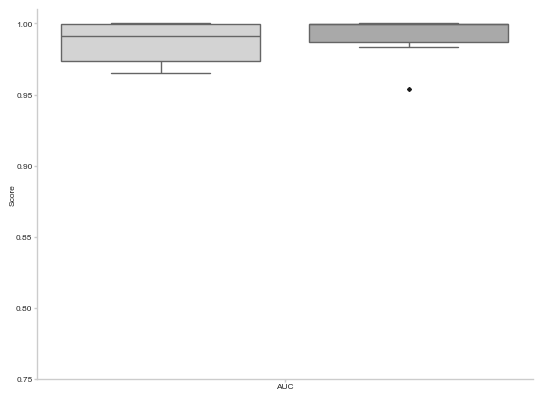

In [37]:
def plot_performance(df_, metric, do_yaxis=True, ax=None):
    df = df_[df_['Metric']==metric].copy()
    df['Epi_Method'] = df['Epitope'] + '_' + df['Method']
    order = [el for el in ['AUC', 'APS', 'Acc', 'F1', 'Precision', 'Recall'] if el in df['Metric'].values]
    df['x'] = df['Method'].map({'Base': 0, 'CloneModel': 0.8})
    df['exp_offset'] = df['Experiment'].map({'first': 0, 'second': 0.2, 'third': 0.4})
    df['epi_offset'] = df['Epitope'].map({'LTD': 0, 'YLQ': 0.1})
    df['x'] = df['x'] + df['exp_offset'] + df['epi_offset']
    
    palette_custom = {'Base': 'lightgray', 'CloneModel': 'darkgray'}
    plot = sb.boxplot(data=df, y='Value', x='Method', 
                      ax=ax, #order=['Base', 'CloneModel'],
                      palette=palette_custom, flierprops={'marker': 'D', 'markerfacecolor': 'k', 
                                                          'markeredgecolor': 'k', 'markersize': 2}
                 )

    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Score', labelpad=0)
    plot.set_xlabel(None)
    plot.legend().remove()
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    #plot.set_xlim((-0.3, 1.6))
    plot.set_xticks([0.5])
    plot.set_xticklabels([metric])
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    plot.set_ylim((-0.05, 1.05))
    plot.set_ylim((0.75, 1.01))
    

    if not do_yaxis:
        plot.yaxis.set_visible(False)
        sb.despine(ax=plot, left=True)  

plot_performance(results_score, 'AUC', do_yaxis=True)

## Motifs

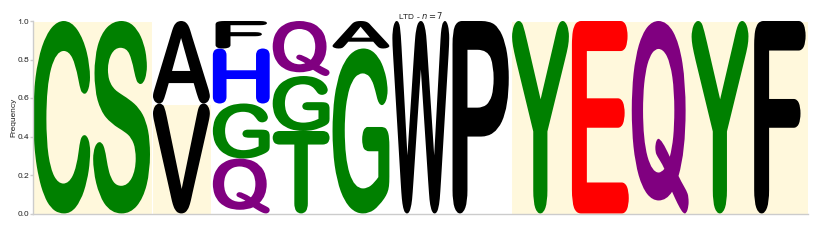

In [38]:
def plot_motifs(epitope, ax=None):   
    seqs = sequences[epitope]
    n_seqs = len(seqs)
    seqs = seqs['cdr3_b'].apply(lambda x: pd.Series(list(x)))
    seqs.columns = [el for el in seqs.columns]
    seqs = seqs.apply(pd.value_counts).transpose() / len(seqs)
    seqs = seqs.fillna(0.0)
    seqs[seqs < 0.10] = 0
    if '-' in seqs.columns:
        seqs = seqs.drop(columns=['-'])
    logo = lm.Logo(seqs, stack_order='small_on_top', color_scheme='chemistry', font_name='Arial Rounded MT Bold', ax=ax)
    plot = logo.ax

    sb.despine(ax=plot)
    plot.set_ylabel('Frequency', labelpad=1)
    plot.set_xticks([])
    plot.set_xticklabels([])
    plot.grid(False)

    if epitope == 'LTD':
        logo.highlight_position_range(pmin=0, pmax=1, color='cornsilk')
        rect = patches.Rectangle((1.5, 0), 1, 4/7, facecolor='cornsilk', zorder=-2)
        plot.add_patch(rect)
        logo.highlight_position_range(pmin=8, pmax=12, color='cornsilk')
    elif epitope == 'YLQ':
        #logo.highlight_position_range(pmin=13, pmax=13, color='cornsilk')
        logo.highlight_position_range(pmin=13, pmax=17, color='cornsilk')

        for p, h in [(10.5, 46/48), (11.5, 46/48)]:
            rect = patches.Rectangle((p, 0), 1, h, facecolor='cornsilk', zorder=-2)
            ax.add_patch(rect)

    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
            
    plot.set_title(f'{epitope} - $n={n_seqs}$', pad=0)
    
plot_motifs('LTD')

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\2737625699.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


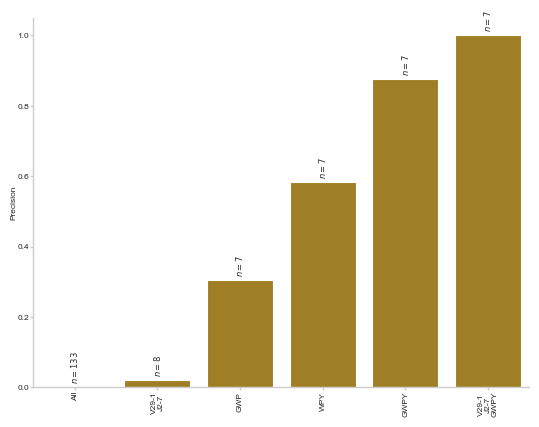

In [39]:
def plot_precision(df, epitope, ax=None):
    plot = sb.barplot(data=df, x='Method', y='Precision', ax=ax, color=palette_epitopes[epitope])
    
    sb.despine(ax=plot)
    plot.set_ylabel('Precision', labelpad=1)
    plot.set_xlabel(None)
    plot.grid(False)

    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
    
    for i, (val, h) in enumerate(zip(df['n_pos'].values, df['Precision'].values)):
        plot.text(i, h + 0.01 * df['Precision'].max(),
                  f'$n={val}$', rotation=90, weight='bold',
                 ha='center', va='bottom')  # above bars

plot_precision(df_precision_ltd, 'LTD')

# Grid layout

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\4021991066.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend(loc='upper right', frameon=False)
C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\4021991066.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend(loc='upper right', frameon=False)
C:\Users\felix.drost\Anaconda3\envs\dextra\lib\site-packages\scanpy\plotting\_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\3856691868.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label star

LTDEMIAQY
6.749749337997426e-12
YLQPRTFLL
0.0


C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1330448516.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1330448516.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1330448516.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1330448516.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are

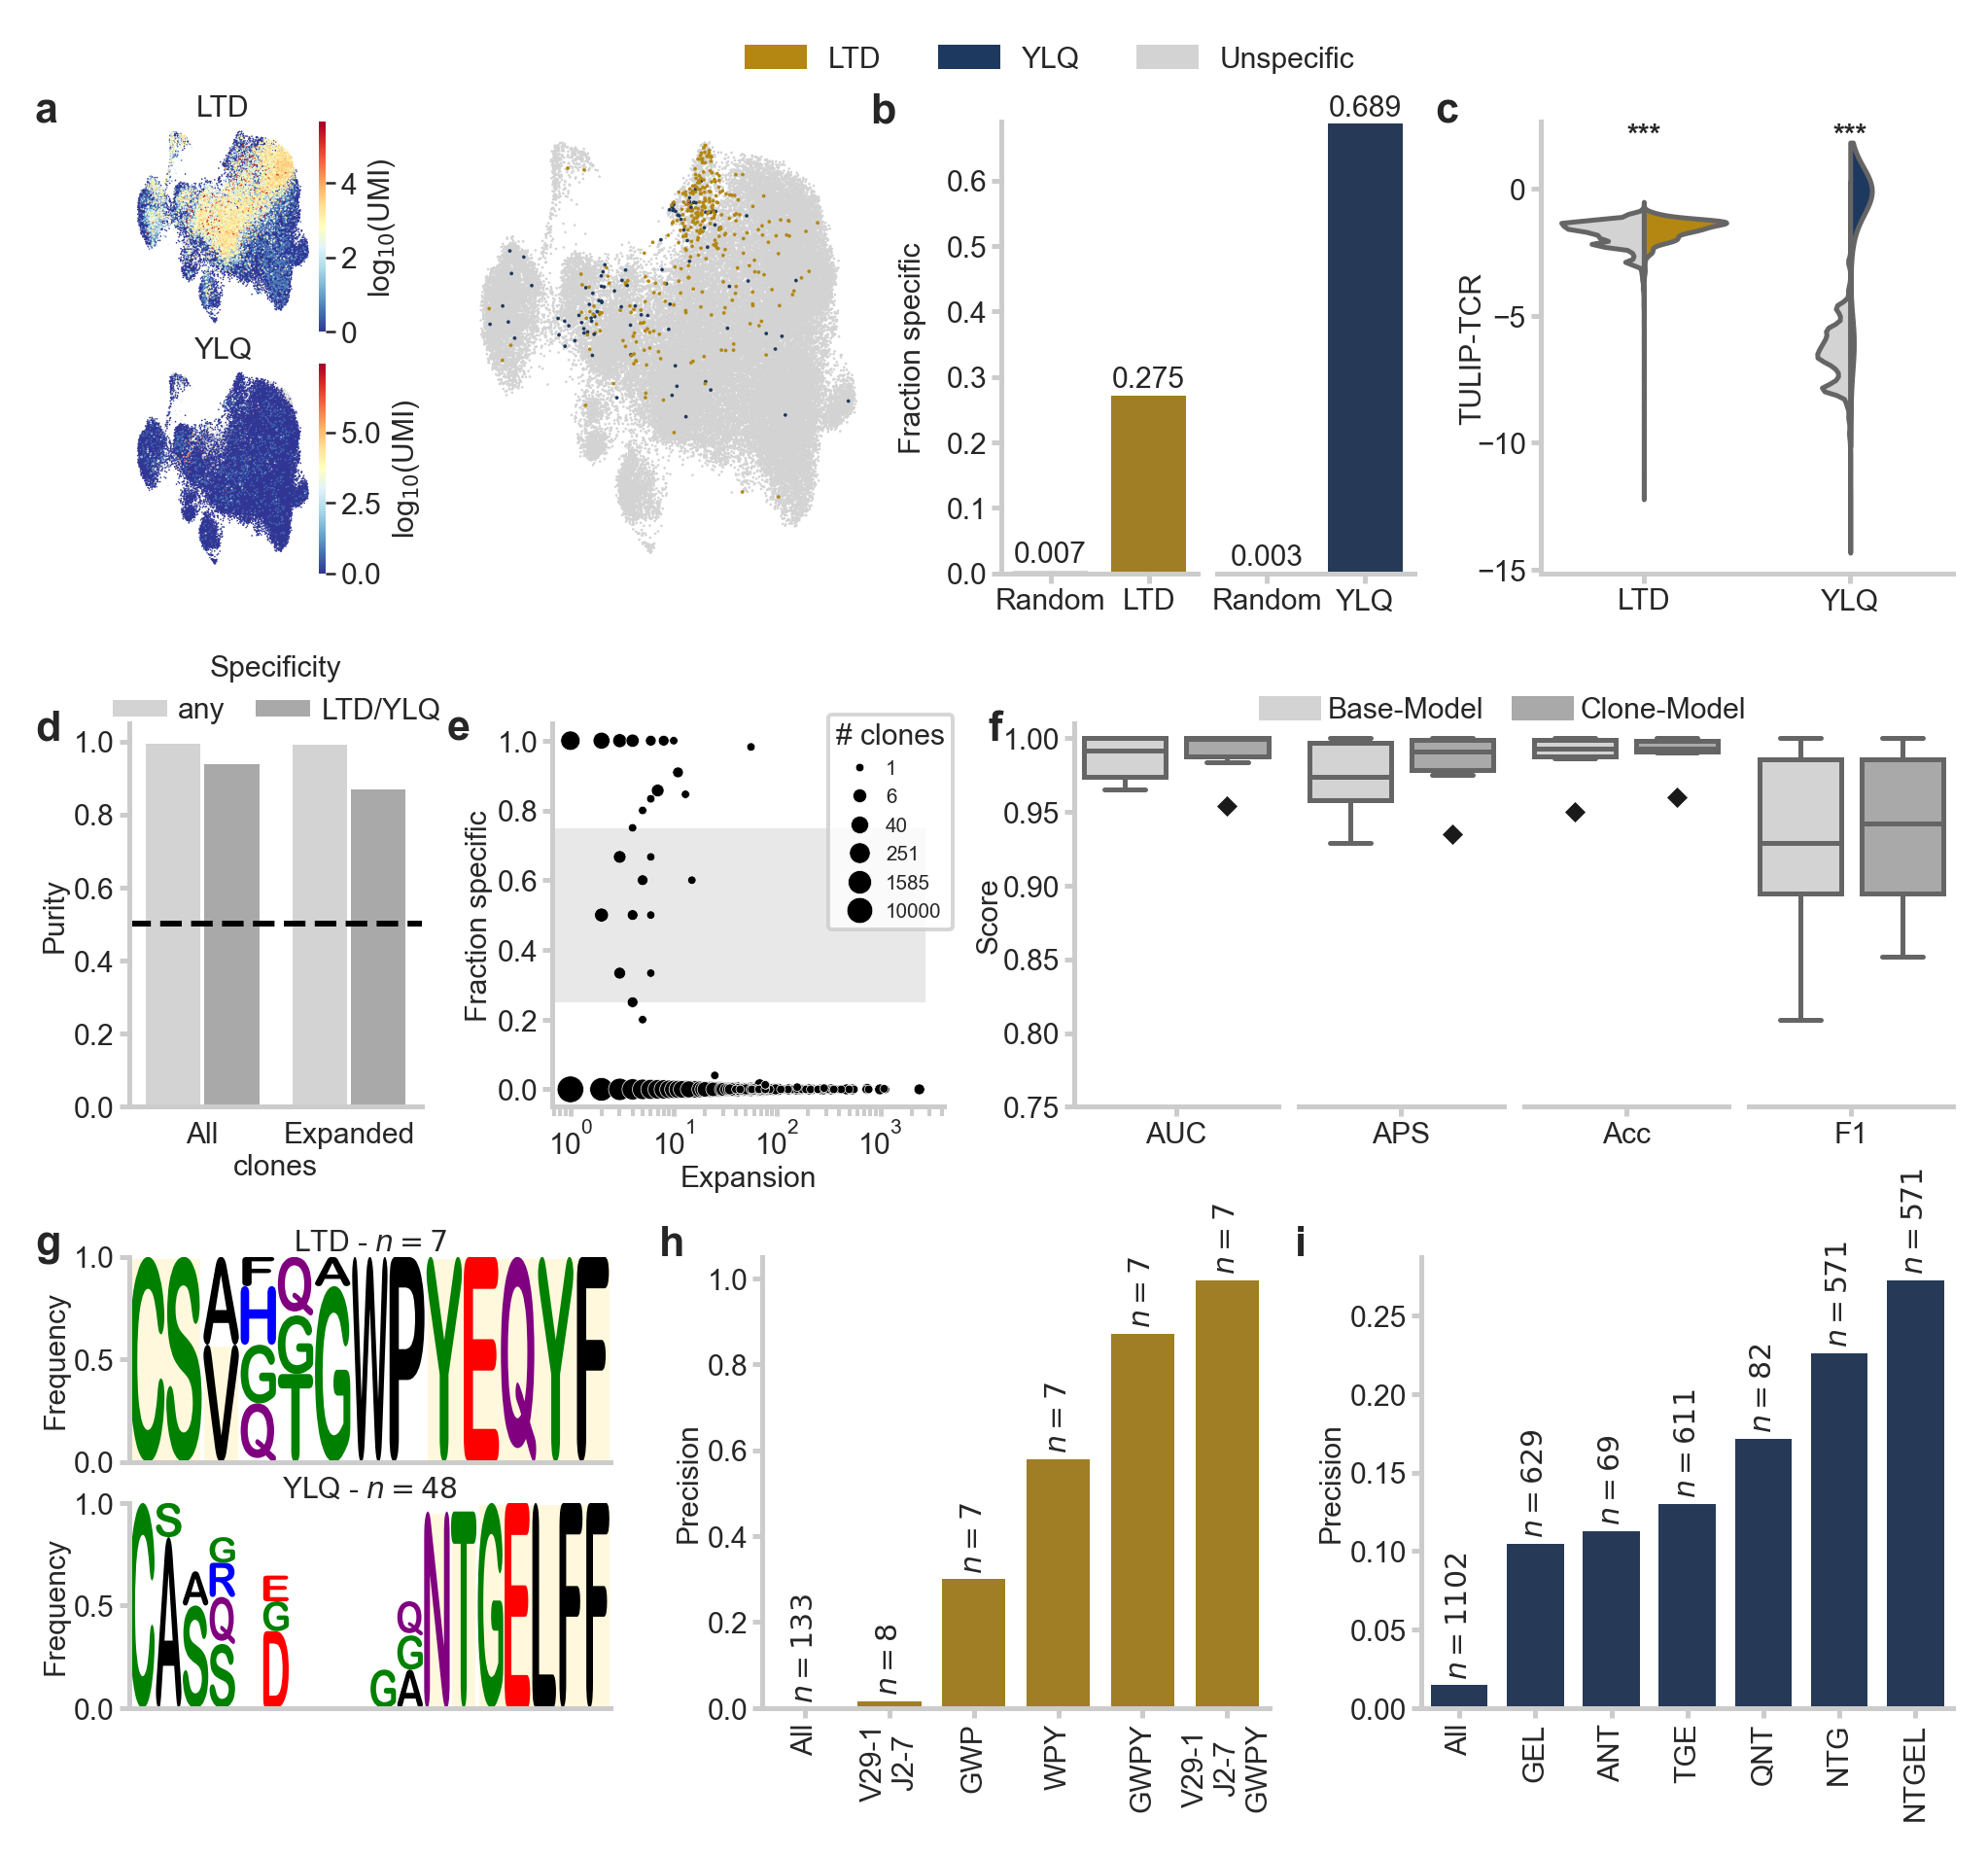

In [40]:
scale = 1
fig = plt.figure(figsize=(TEXT_WIDTH * scale, TEXT_WIDTH * scale * 0.875), #0.65
                 dpi=DPI)

gridspecs = {}

gridspecs["full"] = mpl.gridspec.GridSpec(
    figure=fig,
    nrows=3,
    ncols=1,
    height_ratios=[1, 0.85, 1],
    width_ratios=[1],
    hspace=0.35
)

gridspecs["a-c"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][0],
    nrows=1,
    ncols=4,
    height_ratios=[1],
    width_ratios=[0.5, 1, 1, 1 ],
    hspace=0.1,
    wspace=0.35
)

gridspecs["b"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs["a-c"][2],
    nrows=1,
    ncols=2,
    height_ratios=[1],
    width_ratios=[1, 1 ],
    wspace=0.1
)

gridspecs["a12"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs["a-c"][0],
    nrows=2,
    ncols=1,
    height_ratios=[1, 1],
    width_ratios=[1],
    hspace=0.15
)

gridspecs["d-f"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][1],
    nrows=1,
    ncols=3,
    height_ratios=[1],
    width_ratios=[0.75, 1, 2.25],
    wspace=0.25,
)

gridspecs["f"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['d-f'][2],
    nrows=1,
    ncols=4,
    height_ratios=[1],
    width_ratios=[2, 2, 2, 2],
    wspace=0.1,
)

gridspecs["g-h"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][2],
    nrows=1,
    ncols=3,
    height_ratios=[1],
    width_ratios=[0.95, 1, 1.05],
    wspace=0.3
)

gridspecs["g"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['g-h'][0],
    nrows=2,
    ncols=1,
    height_ratios=[1, 1],
    width_ratios=[1, ],
    wspace=0.3
)

ax_a1 = fig.add_subplot(gridspecs["a12"][0])
ax_a2 = fig.add_subplot(gridspecs["a12"][1])
ax_a3 = fig.add_subplot(gridspecs["a-c"][1])
ax_b1 = fig.add_subplot(gridspecs["b"][0])
ax_b2 = fig.add_subplot(gridspecs["b"][1])
ax_c = fig.add_subplot(gridspecs["a-c"][3])

ax_d = fig.add_subplot(gridspecs["d-f"][0])
ax_e = fig.add_subplot(gridspecs["d-f"][1])
ax_f1 = fig.add_subplot(gridspecs["f"][0])
ax_f2 = fig.add_subplot(gridspecs["f"][1])
ax_f3 = fig.add_subplot(gridspecs["f"][2])
ax_f4 = fig.add_subplot(gridspecs["f"][3])

ax_g1 = fig.add_subplot(gridspecs["g"][0])
ax_g2 = fig.add_subplot(gridspecs["g"][1])
ax_h1 = fig.add_subplot(gridspecs["g-h"][1])
ax_h2 = fig.add_subplot(gridspecs["g-h"][2])

plot_umi_umap('LTDEMIAQY', ax=ax_a1)
plot_umi_umap('YLQPRTFLL', ax=ax_a2)
plot_umap_binding(ax_a3)

plot_nn(df_nn_ltd, ax=ax_b1)
plot_nn(df_nn_ylq, do_yaxis=False, ax=ax_b2)

plot_violin(df_prediction, ax=ax_c)

plot_purity(ax=ax_d)
plot_purity_expansion(df_purity_all, ax=ax_e)

plot_performance(results_score, 'AUC', ax=ax_f1)
plot_performance(results_score, 'APS', do_yaxis=False, ax=ax_f2)

plot_performance(results_class, 'Acc', do_yaxis=False, ax=ax_f3)
plot_performance(results_class, 'F1', do_yaxis=False, ax=ax_f4)

palette_custom = {'Base-Model': 'lightgray', 'Clone-Model': 'darkgray'}
handles = [mpatches.Patch(color=color, label=label) for label, color in palette_custom.items()]
ax_f2.legend(handles=handles, frameon=False, ncols=2, loc='lower center', bbox_to_anchor=(1, 0.93),
             columnspacing=1, handletextpad=0.3)

plot_motifs('LTD', ax_g1)
plot_motifs('YLQ', ax_g2)
plot_precision(df_precision_ltd, 'LTD', ax=ax_h1)
plot_precision(df_precision_ylq, 'YLQ', ax=ax_h2)

fig.text(0.085, 0.88, 'a', size='x-large', weight='bold')
fig.text(0.44, 0.88, 'b', size='x-large', weight='bold')
fig.text(0.68, 0.88, 'c', size='x-large', weight='bold')
fig.text(0.085, 0.58, 'd', size='x-large', weight='bold')
fig.text(0.26, 0.58, 'e', size='x-large', weight='bold')
fig.text(0.49, 0.58, 'f', size='x-large', weight='bold')
fig.text(0.085, 0.33, 'g', size='x-large', weight='bold')
fig.text(0.35, 0.33, 'h', size='x-large', weight='bold')
fig.text(0.62, 0.33, 'i', size='x-large', weight='bold')


fig.savefig('../figures/fig_kocher.pdf',
           dpi=DPI, bbox_inches='tight')
fig.savefig('../figures/fig_kocher.png',
           dpi=DPI, bbox_inches='tight')
plt.show()

## Supplementary Figures

In [41]:
from matplotlib.lines import Line2D

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1601234002.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette.items()]
C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1601234002.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette_epitopes.items()]


LTDEMIAQY
5.4918088137575864
YLQPRTFLL
60.62628996212479


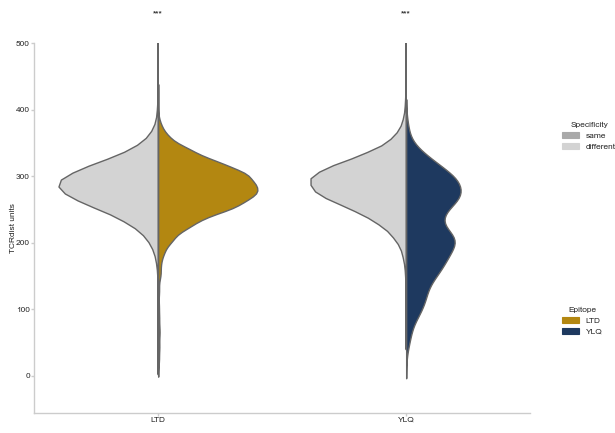

In [42]:
def plot_violin_pairwise(ax=None):
    palette = {'same': 'darkgray', 'different': 'lightgray'}
    plot = sb.violinplot(data=df_dist_pairs, hue=f'sameSpec', y='TCRdist', ax=ax, x='Epitope', split=True,
                  order=['LTD', 'YLQ'], hue_order=['different', 'same'], inner=None,
                 palette=palette, linewidth=1,
                 )
    
    sb.despine(ax=plot)
    plot.set_ylabel('TCRdist units', labelpad=0)
    plot.grid(False)
    plot.set_xlabel(None)
    
    handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette.items()]
    legend_1 = plot.legend(handles=handles, title='Specificity', bbox_to_anchor=(1.05, 0.75), loc='center left', frameon=False)
    
    plot.add_artist(legend_1)
    
    handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette_epitopes.items()]
    plot.legend(handles=handles, title='Epitope', bbox_to_anchor=(1.05, 0.25), loc='center left', frameon=False)
    
    
    plot.set_ylim((plot.get_ylim()[0], 500))
    
    for i, epitope in enumerate(epitopes):
        print(epitope)
        tmp = df_dist_pairs[df_dist_pairs['Epitope']==epitope[:3]]
        _, pval = ttest_ind(tmp[tmp['sameSpec']=='different']['TCRdist'].values, 
                            tmp[tmp['sameSpec']=='same']['TCRdist'].values, )
        
        y_max = plot.get_ylim()[1] + 50
        plot.text(i, y_max, pval_to_sign(pval), ha='center', va='top', weight='bold')
        print(tmp[tmp['sameSpec']=='different']['TCRdist'].values.mean() - 
                            tmp[tmp['sameSpec']=='same']['TCRdist'].values.mean())
        
        
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    
        
    for i, collection in enumerate(plot.collections):
        path = collection.get_paths()[0]
        x_center = path.vertices[:, 0].mean()
        ep = 'LTD' if x_center < 0.5 else 'YLQ'
        spec = 'unspec' if i%2==0 else 'spec'
            
        color = f'{ep}_{spec}'
        collection.set_facecolor(palette_epitopes_ext[color])
        
plot_violin_pairwise(ax=None)

In [43]:
palette_model_2 = {
    'LTD': {
        'Base': palette_model['LTD_Base'],
        'CloneModel': palette_model['LTD_CloneModel'],
    },
    'YLQ': {
        'Base': palette_model['YLQ_Base'],
        'CloneModel': palette_model['YLQ_CloneModel'],
    }
}

,Method,Epitope,Experiment,Baseline,Metric,Value,Epi_Method,x,exp_offset,epi_offset
16,Base,YLQ,first,paper,AUC,1.000000,YLQ_Base,0.00,0.00,0.1
34,Base,YLQ,second,paper,AUC,0.965297,YLQ_Base,0.15,0.15,0.1
52,Base,YLQ,third,paper,AUC,0.999016,YLQ_Base,0.30,0.30,0.1
70,CloneModel,YLQ,first,paper,AUC,1.000000,YLQ_CloneModel,0.80,0.00,0.1
88,CloneModel,YLQ,second,paper,AUC,0.954061,YLQ_CloneModel,0.95,0.15,0.1
106,CloneModel,YLQ,third,paper,AUC,0.999016,YLQ_CloneModel,1.10,0.30,0.1


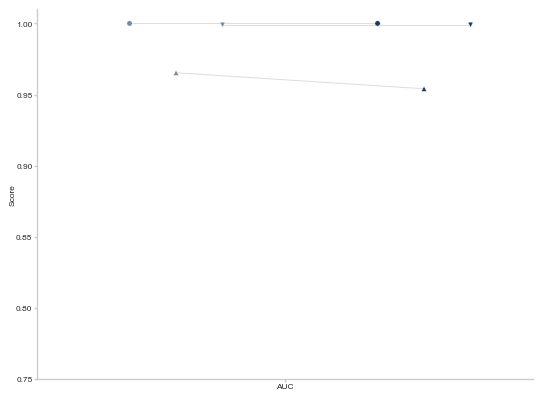

In [44]:
def plot_performance_scatter(df_, metric, epi, do_yaxis=True, ax=None):
    df = df_[(df_['Metric']==metric) & (df_['Epitope']==epi)].copy()
    df['Epi_Method'] = df['Epitope'] + '_' + df['Method']
    order = [el for el in ['AUC', 'APS', 'Acc', 'F1', 'Precision', 'Recall'] if el in df['Metric'].values]
    df['x'] = df['Method'].map({'Base': 0, 'CloneModel': 0.8})
    df['exp_offset'] = df['Experiment'].map({'first': 0, 'second': 0.15, 'third': 0.3})
    df['epi_offset'] = df['Epitope'].map({'LTD': 0, 'YLQ': 0.1})
    df['x'] = df['x'] + df['exp_offset'] #+ df['epi_offset']
    
    marker_map = {'first': 'o', 'second': '^', 'third': 'v'}
    plot = sb.scatterplot(data=df, y='Value', x='x', hue='Method', style='Experiment', markers=marker_map,
                      ax=ax, #order=['Base', 'CloneModel'],
                      palette=palette_model_2[epi], 
                          s=15, zorder=2
                 )

    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Score', labelpad=0)
    plot.set_xlabel(None)
    plot.legend().remove()
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.set_xlim((-0.3, 1.3))
    plot.set_xticks([0.5])
    plot.set_xticklabels([metric])
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    plot.set_ylim((0.75, 1.01))
    

    if not do_yaxis:
        plot.yaxis.set_visible(False)
        sb.despine(ax=plot, left=True)
        
    
    for exp in df['Experiment'].unique():
        x = df[df['Experiment']==exp]['x'].values
        y = df[df['Experiment']==exp]['Value'].values
        plot.plot([x[0], x[1]], [y[0], y[1]], color='lightgrey', alpha=0.75, zorder=1, linewidth=0.75)
    
    return df


plot_performance_scatter(results_score, 'AUC', 'YLQ', do_yaxis=True)

C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1601234002.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette.items()]
C:\Users\felix.drost\AppData\Local\Temp\ipykernel_17460\1601234002.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette_epitopes.items()]


LTDEMIAQY
5.4918088137575864
YLQPRTFLL
60.62628996212479


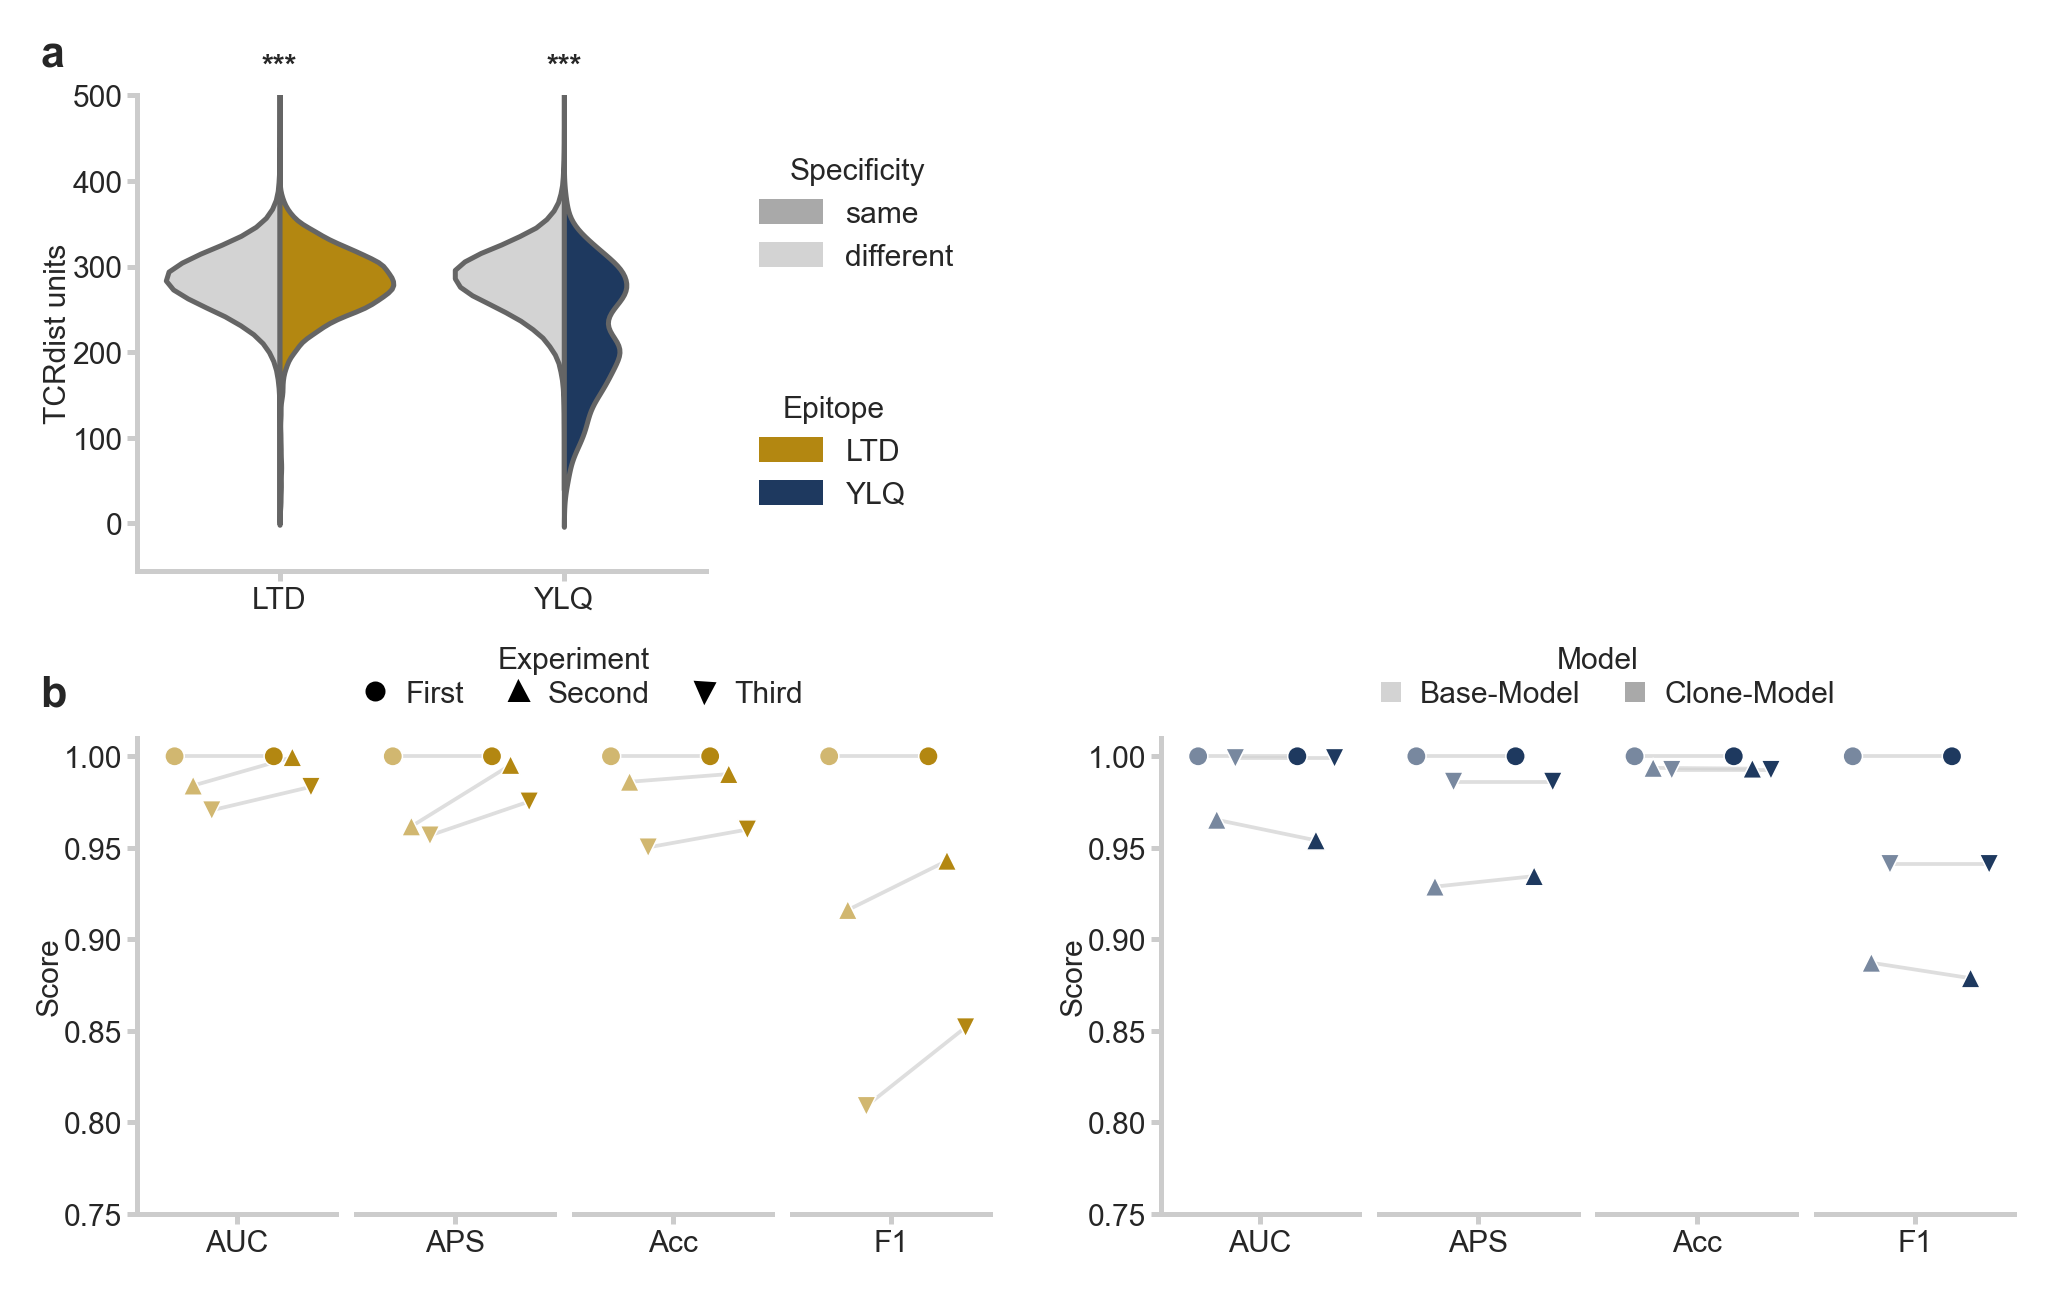

In [45]:
scale = 1
fig = plt.figure(figsize=(TEXT_WIDTH * scale, TEXT_WIDTH * scale * 0.6), #0.65
                 dpi=DPI)

gridspecs = {}

gridspecs["full"] = mpl.gridspec.GridSpec(
    figure=fig,
    nrows=2,
    ncols=1,
    height_ratios=[1, 1],
    width_ratios=[1],
    hspace=0.35
)

gridspecs["a"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][0],
    nrows=1,
    ncols=2,
    height_ratios=[1],
    width_ratios=[1, 2],
)

gridspecs["b"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][1],
    nrows=1,
    ncols=2,
    height_ratios=[1],
    width_ratios=[1, 1],
    wspace=0.2
)

gridspecs["b_LTD"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['b'][0],
    nrows=1,
    ncols=4,
    height_ratios=[1],
    width_ratios=[1, 1, 1, 1],
    wspace=0.1
)

gridspecs["b_YLQ"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['b'][1],
    nrows=1,
    ncols=4,
    height_ratios=[1],
    width_ratios=[1, 1, 1, 1],
    wspace=0.1
)


ax_a1 = fig.add_subplot(gridspecs["a"][0])
ax_a2 = fig.add_subplot(gridspecs["a"][1])

plot_violin_pairwise(ax=ax_a1)
ax_a2.axis(False)


for j, epi in enumerate(['LTD', 'YLQ']):
    for i, m in enumerate(['AUC', 'APS', 'Acc', 'F1']):
        ax_b_tmp = fig.add_subplot(gridspecs[f"b_{epi}"][i])
        results = results_score if i < 2 else results_class
        plot_performance_scatter(results, m, epi, do_yaxis=i==0, ax=ax_b_tmp)
        
        if i == 2:
            if j == 0:
                marker_map = {'First': 'o', 'Second': '^', 'Third': 'v'}
                handles = [Line2D([0], [0], marker=marker, linestyle='', color='black', label=label, markersize=3) 
                           for label, marker in marker_map.items()]
                ax_b_tmp.legend(handles=handles, title="Experiment", bbox_to_anchor=(0, 1.25), loc='upper center', 
                                frameon=False, ncols=3, columnspacing=0.8, handletextpad=0.0, labelspacing=0.2)
                
            if j == 1:
                handles = [Line2D([0], [0], marker='s', color=color, linestyle='', markersize=3, label=label)
                           for label, color in palette_custom.items()]
                ax_b_tmp.legend(handles=handles, title="Model", bbox_to_anchor=(0, 1.25), loc='upper center', 
                                frameon=False, ncols=3, columnspacing=0.8, handletextpad=0.0, labelspacing=0.2)



fig.text(0.085, 0.9, 'a', size='x-large', weight='bold')
fig.text(0.085, 0.46, 'b', size='x-large', weight='bold')

#fig.tight_layout()
fig.savefig('../figures/sfig1_kocher.pdf',
           dpi=DPI, bbox_inches='tight')
fig.savefig('../figures/sfig1_kocher.png',
           dpi=DPI, bbox_inches='tight')
plt.show()